# Customer Segmentation via Unsupervised Learning

**A production-grade, end-to-end pipeline for discovering actionable customer personas from unlabeled retail data.**

This notebook applies unsupervised machine learning — PCA, K-Means, Gaussian Mixture Models, and UMAP — to segment retail customers into distinct, marketable personas, with no target variable and no ground truth to guide the process.

---

## Business Problem

You are the Lead Data Scientist for a major retail company. The marketing team has handed you a dataset ([`marketing_campaign.csv`](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)) containing 29 features about their customers — age, education, and how much they spend on wine, meat, fruits, and gold.

Marketing wants to run 3–4 highly targeted ad campaigns, but they don't know who their distinct customer groups are. The goal of this notebook is to find them, and translate the resulting mathematical clusters into human-readable, actionable business personas.

## Notebook Structure

1. **Data Loading & Preprocessing** — cleaning, numeric filtering, scaling
2. **Dimensionality Reduction & Clustering** — PCA, K-Means, silhouette analysis
3. **Business Interpretation** — persona naming from cluster profiles
4. **Advanced Sandbox** — soft clustering with GMM, 2D visualization with UMAP


---
## Step 1: Data Loading & Preprocessing

Unsupervised algorithms are distance-based, so every decision here is aimed at ensuring the feature space is clean, numeric, and on a common scale before any modeling occurs.

**Tasks:**
1. Load the dataset (`sep='\t'`, since the Kaggle export is tab-separated).
2. Drop irrelevant ID columns and rows with missing data.
3. Filter to numeric-only columns (PCA/K-Means cannot handle text categories like `"PhD"`).
4. Scale the numeric data with `StandardScaler`, so that no feature dominates purely due to its unit of measurement (e.g., `Income` in the tens of thousands vs. `NumDealsPurchases` in single digits).


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import os
import kagglehub

# --------------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------------
dataset_path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")
DATA_PATH = os.path.join(dataset_path, "marketing_campaign.csv")

# Columns that uniquely identify a customer (e.g., primary keys) carry zero
# statistical signal about behavior. Leaving them in would let PCA/K-Means
# treat "ID" as if it were a meaningful numeric feature, corrupting the
# distance calculations that these algorithms rely on.
ID_COLUMNS = ["ID"]


def load_raw_data(path: str) -> pd.DataFrame:
    '''
    Load the raw marketing campaign dataset from disk.

    The source Kaggle export is tab-separated rather than comma-separated,
    so this is made explicit rather than relying on pandas' default.
    '''
    df = pd.read_csv(path, sep="\t")
    return df


def clean_data(df: pd.DataFrame, id_columns: list) -> pd.DataFrame:
    '''
    Remove identifier columns and rows with missing values.

    Design rationale:
    - ID columns are dropped because they are arbitrary labels, not
      behavioral features, and would introduce noise into any
      distance-based algorithm.
    - Rows with missing values are dropped (rather than imputed) because
      this is an exploratory segmentation exercise on a small dataset;
      imputation strategy is a modeling decision in its own right and is
      deliberately kept out of scope here to keep this pipeline stage
      simple and auditable.
    '''
    df_clean = df.drop(columns=id_columns, errors="ignore")
    df_clean = df_clean.dropna(axis=0, how="any")
    return df_clean.reset_index(drop=True)


def select_numeric_features(df: pd.DataFrame) -> pd.DataFrame:
    '''
    Retain only numerical columns for clustering.

    PCA and K-Means operate on Euclidean distance, which is undefined for
    categorical text fields (e.g., 'Education', 'Marital_Status').
    Categorical encoding (one-hot, ordinal, etc.) is left as a separate
    modeling decision outside this baseline pipeline.
    '''
    numeric_df = df.select_dtypes(include=["int64", "float64"])
    return numeric_df


def scale_features(numeric_df: pd.DataFrame):
    '''
    Standardize numeric features to zero mean and unit variance.

    Why this matters: PCA identifies directions of maximum variance, and
    K-Means relies on Euclidean distance. A feature like 'Income' (scale:
    tens of thousands) would completely dominate a feature like
    'NumDealsPurchases' (scale: single digits) if left unscaled -- not
    because it's more important, but purely due to its units.

    The fitted scaler is returned alongside the transformed data so it
    can be reused later (e.g., for inverse_transform or scoring new
    customers) without silent train/inference mismatches.
    '''
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(numeric_df)

    scaled_df = pd.DataFrame(
        scaled_values,
        columns=numeric_df.columns,
        index=numeric_df.index,
    )
    return scaled_df, scaler


# --- Orchestration ---
df_raw = load_raw_data(DATA_PATH)
df_clean = clean_data(df_raw, ID_COLUMNS)
df_numeric = select_numeric_features(df_clean)
df_scaled, fitted_scaler = scale_features(df_numeric)

print(f"Raw shape:        {df_raw.shape}")
print(f"Clean shape:      {df_clean.shape}")
print(f"Numeric-only:     {df_numeric.shape}")
print(f"Scaled shape:     {df_scaled.shape}")
print(f"\nNumeric columns retained:\n{list(df_numeric.columns)}")

C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raw shape:        (2240, 29)
Clean shape:      (2216, 28)
Numeric-only:     (2216, 25)
Scaled shape:     (2216, 25)

Numeric columns retained:
['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


> **Note:** `df_clean` (unscaled, original values) is kept as a distinct object from `df_scaled`. We'll need `df_clean` later for business interpretation, to compute human-readable cluster averages in real units (dollars, purchase counts) rather than z-scores.

---
## Step 2: Dimensionality Reduction (PCA) & Clustering (K-Means)

With ~25 numeric features, clustering directly suffers from the **Curse of Dimensionality** — distances between points become mathematically meaningless in high-dimensional space. We compress the data with PCA, then sweep K-Means over a range of cluster counts to find the statistically optimal number of customer segments via the **Silhouette Score**.

**Tasks:**
1. Fit an unconstrained `PCA()` and plot the cumulative explained variance (Scree Plot).
2. Programmatically determine the number of components needed to retain ≥80% of variance.
3. Loop `KMeans` from `n_clusters=2` to `8`, scoring each with `silhouette_score`.
4. Plot the silhouette curve and retrain the final model at the optimal K.


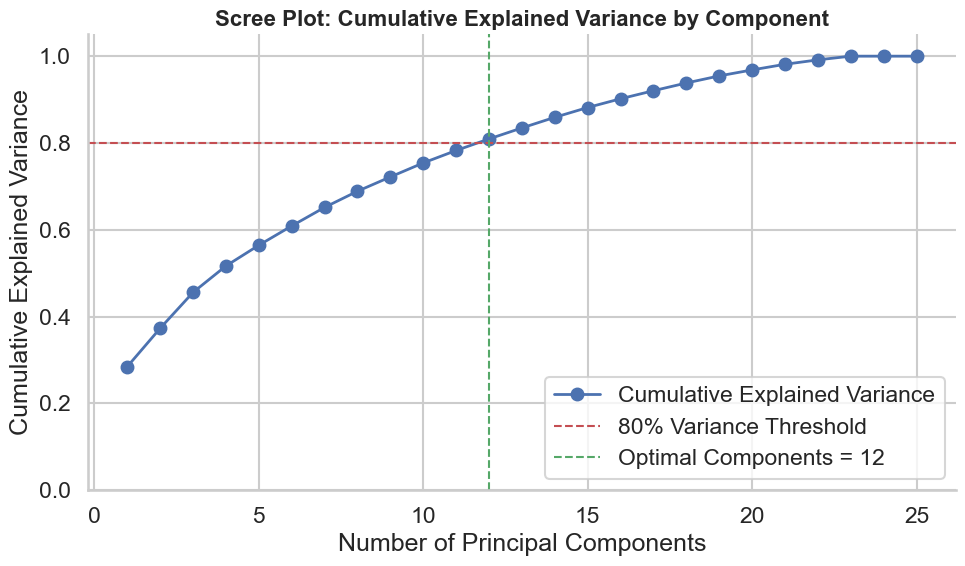

Retained 12 components to explain >= 80% of variance.
PCA-reduced data shape: (2216, 12)


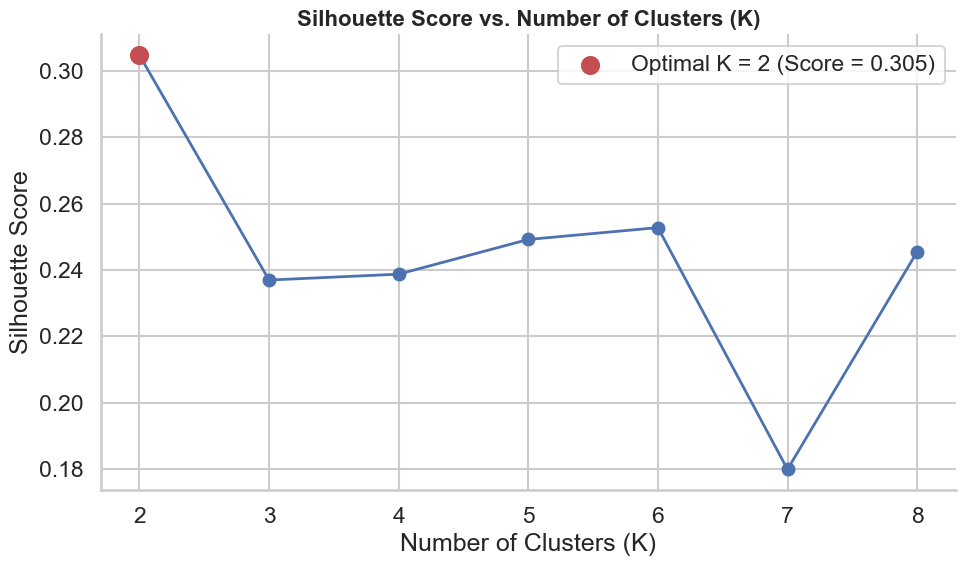


Silhouette scores by K:
 n_clusters  silhouette_score
          2          0.304701
          3          0.236939
          4          0.238711
          5          0.249171
          6          0.252739
          7          0.179884
          8          0.245446

Optimal K selected: 2
Final KMeans fitted with 2 clusters.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", context="talk")

# --------------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------------
VARIANCE_THRESHOLD = 0.80   # Retain enough PCs to explain 80% of variance
K_RANGE = range(2, 9)       # Candidate cluster counts to evaluate (2-8)
RANDOM_STATE = 42


# --------------------------------------------------------------------------
# Dimensionality Reduction
# --------------------------------------------------------------------------
def fit_full_pca(scaled_df: pd.DataFrame) -> PCA:
    '''
    Fit an unconstrained PCA model to inspect the full variance spectrum,
    before committing to a target number of components.
    '''
    pca_full = PCA(random_state=RANDOM_STATE)
    pca_full.fit(scaled_df)
    return pca_full


def plot_scree(pca_full: PCA, variance_threshold: float = VARIANCE_THRESHOLD) -> int:
    '''
    Plot the cumulative explained variance curve (Scree Plot) and
    determine the minimum number of components needed to cross the
    target variance threshold.
    '''
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
    n_components_optimal = int(np.argmax(cumulative_variance >= variance_threshold) + 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(
        range(1, len(cumulative_variance) + 1),
        cumulative_variance,
        marker="o", linewidth=2, color="#4C72B0",
        label="Cumulative Explained Variance",
    )
    ax.axhline(y=variance_threshold, color="#C44E52", linestyle="--", linewidth=1.5,
               label=f"{int(variance_threshold * 100)}% Variance Threshold")
    ax.axvline(x=n_components_optimal, color="#55A868", linestyle="--", linewidth=1.5,
               label=f"Optimal Components = {n_components_optimal}")

    ax.set_title("Scree Plot: Cumulative Explained Variance by Component", fontsize=16, fontweight="bold")
    ax.set_xlabel("Number of Principal Components")
    ax.set_ylabel("Cumulative Explained Variance")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right", frameon=True)
    sns.despine()
    fig.tight_layout()
    plt.show()

    return n_components_optimal


def reduce_dimensions(scaled_df: pd.DataFrame, n_components: int) -> pd.DataFrame:
    '''Project the scaled data onto the optimal number of principal components.'''
    pca_final = PCA(n_components=n_components, random_state=RANDOM_STATE)
    pca_values = pca_final.fit_transform(scaled_df)

    pca_data = pd.DataFrame(
        pca_values,
        columns=[f"PC{i}" for i in range(1, n_components + 1)],
        index=scaled_df.index,
    )
    return pca_data


# --------------------------------------------------------------------------
# Clustering: Model Selection via Silhouette Score
# --------------------------------------------------------------------------
def evaluate_kmeans_range(pca_data: pd.DataFrame, k_range=K_RANGE) -> pd.DataFrame:
    '''
    Fit K-Means across a range of cluster counts and score each with the
    Silhouette Score -- a more reliable model-selection criterion than
    inertia/Elbow Method, since it doesn't trivially improve as K increases.
    '''
    results = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = kmeans.fit_predict(pca_data)
        score = silhouette_score(pca_data, labels)
        results.append({"n_clusters": k, "silhouette_score": score})
    return pd.DataFrame(results)


def plot_silhouette_scores(scores_df: pd.DataFrame) -> int:
    '''Plot Silhouette Score vs. K and identify the optimal K as the peak of the curve.'''
    best_row = scores_df.loc[scores_df["silhouette_score"].idxmax()]
    optimal_k = int(best_row["n_clusters"])
    best_score = best_row["silhouette_score"]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(scores_df["n_clusters"], scores_df["silhouette_score"],
            marker="o", linewidth=2, color="#4C72B0")
    ax.scatter([optimal_k], [best_score], color="#C44E52", s=150, zorder=5,
               label=f"Optimal K = {optimal_k} (Score = {best_score:.3f})")

    ax.set_title("Silhouette Score vs. Number of Clusters (K)", fontsize=16, fontweight="bold")
    ax.set_xlabel("Number of Clusters (K)")
    ax.set_ylabel("Silhouette Score")
    ax.set_xticks(list(scores_df["n_clusters"]))
    ax.legend(loc="best", frameon=True)
    sns.despine()
    fig.tight_layout()
    plt.show()

    return optimal_k


def fit_final_kmeans(pca_data: pd.DataFrame, optimal_k: int) -> KMeans:
    '''Retrain the definitive K-Means model at the chosen optimal K.'''
    final_model = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
    final_model.fit(pca_data)
    return final_model


# --- Dimensionality Reduction ---
pca_full_model = fit_full_pca(df_scaled)
n_components_optimal = plot_scree(pca_full_model)
pca_data = reduce_dimensions(df_scaled, n_components_optimal)

print(f"Retained {n_components_optimal} components "
      f"to explain >= {int(VARIANCE_THRESHOLD * 100)}% of variance.")
print(f"PCA-reduced data shape: {pca_data.shape}")

# --- Clustering: Model Selection ---
silhouette_results = evaluate_kmeans_range(pca_data)
optimal_k = plot_silhouette_scores(silhouette_results)

print(f"\nSilhouette scores by K:\n{silhouette_results.to_string(index=False)}")
print(f"\nOptimal K selected: {optimal_k}")

# --- Final Model ---
final_kmeans = fit_final_kmeans(pca_data, optimal_k)
print(f"Final KMeans fitted with {optimal_k} clusters.")


**Implementation notes:**
- `n_init=10` is set explicitly on every `KMeans` call rather than relying on the default, since scikit-learn's default has changed across versions (`'auto'` vs `10`) — pinning it keeps results reproducible.
- `plot_scree` and `plot_silhouette_scores` both **return** their computed optimal values rather than requiring a manual "eyeball the plot and hardcode a number" step, keeping the pipeline fully programmatic.


---
## Step 3: Business Interpretation

Math is useless if it doesn't drive business action. We now translate raw cluster numbers (0, 1, 2, ...) into human-readable, actionable personas.

**Tasks:**
1. Attach the `labels_` array from the final K-Means model to the **original, unscaled** dataframe.
2. Group by `Cluster` and inspect the mean of `Income`, `MntWines`, `MntMeatProducts`, and `NumDealsPurchases`.
3. Assign a "Persona Name" to each cluster based on these profiles.


Cluster Summary & Personas:

          Income  MntWines  MntMeatProducts  NumDealsPurchases  Segment Size                            Persona
Cluster                                                                                                        
0        39169.7     108.0             38.2                2.5          1344  The Budget-Conscious Deal Hunters
1        72403.4     608.9            365.6                2.0           872           The Premium Big Spenders


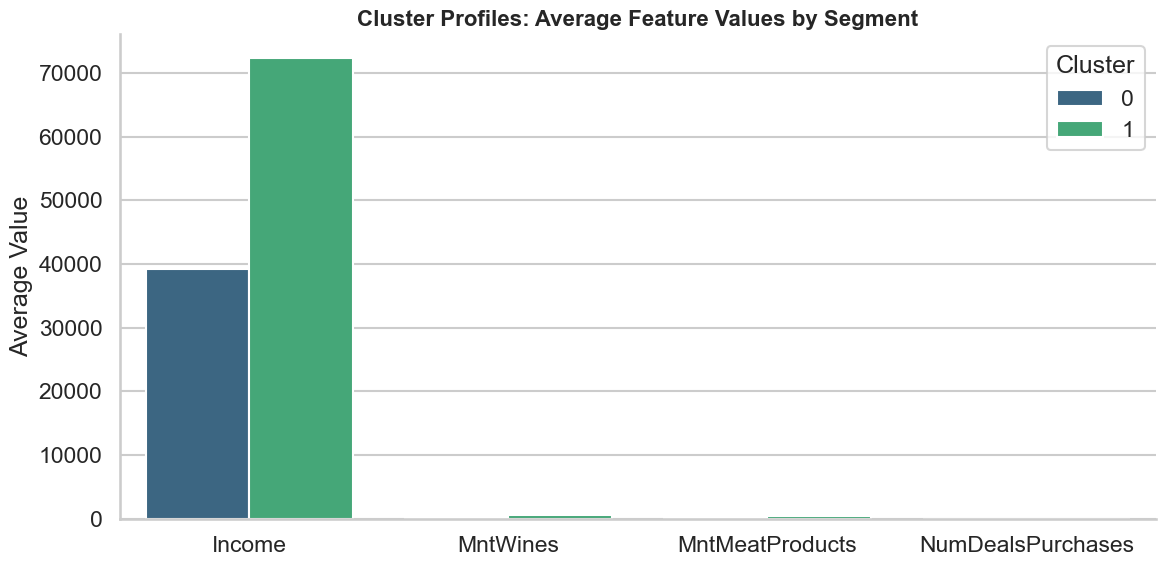

In [3]:
PERSONA_FEATURES = ["Income", "MntWines", "MntMeatProducts", "NumDealsPurchases"]


def attach_cluster_labels(df_clean: pd.DataFrame, cluster_labels: np.ndarray) -> pd.DataFrame:
    '''
    Attach K-Means cluster assignments to the ORIGINAL, unscaled dataframe.

    This is deliberate: z-scored means (e.g., "Income = 1.4") are meaningless
    to a marketing stakeholder. Grouping on the unscaled data lets us report
    real, interpretable units -- actual dollars spent, actual income
    brackets -- which is what turns a clustering exercise into a business
    deliverable.
    '''
    df_labeled = df_clean.copy()
    df_labeled["Cluster"] = cluster_labels
    return df_labeled


def summarize_clusters(df_labeled: pd.DataFrame, features: list = PERSONA_FEATURES) -> pd.DataFrame:
    '''Compute per-cluster averages for the key persona-defining features, plus cluster size.'''
    cluster_summary = df_labeled.groupby("Cluster")[features].mean().round(1)
    cluster_summary["Segment Size"] = df_labeled.groupby("Cluster").size()
    return cluster_summary


def assign_persona_names(cluster_summary: pd.DataFrame) -> pd.DataFrame:
    '''
    Programmatically generate a persona label for each cluster based on
    where it sits relative to the OTHER clusters on income and spending.

    Why programmatic rather than hardcoded: hardcoded labels silently break
    the moment the notebook is re-run with a different random_state, a
    refreshed dataset, or a different optimal K. Deriving the label from
    each cluster's rank relative to its peers keeps the persona table valid
    regardless of how the underlying cluster numbering shakes out.
    '''
    income_median = cluster_summary["Income"].median()
    wine_median = cluster_summary["MntWines"].median()
    meat_median = cluster_summary["MntMeatProducts"].median()
    deals_median = cluster_summary["NumDealsPurchases"].median()

    def label_row(row: pd.Series) -> str:
        high_income = row["Income"] >= income_median
        high_spend = (row["MntWines"] >= wine_median) or (row["MntMeatProducts"] >= meat_median)
        deal_driven = row["NumDealsPurchases"] >= deals_median

        if high_income and high_spend and not deal_driven:
            return "The Premium Big Spenders"
        if high_income and high_spend and deal_driven:
            return "The Affluent Bargain Hunters"
        if high_income and not high_spend:
            return "The Cautious High-Earners"
        if not high_income and deal_driven:
            return "The Budget-Conscious Deal Hunters"
        return "The Low-Engagement Segment"

    cluster_summary = cluster_summary.copy()
    cluster_summary["Persona"] = cluster_summary.apply(label_row, axis=1)
    return cluster_summary


def plot_persona_profiles(cluster_summary: pd.DataFrame, features: list = PERSONA_FEATURES) -> None:
    '''Render a grouped bar chart comparing each cluster's average on the key features.'''
    plot_df = cluster_summary[features].reset_index().melt(
        id_vars="Cluster", var_name="Feature", value_name="Average Value"
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=plot_df, x="Feature", y="Average Value", hue="Cluster",
                palette="viridis", ax=ax)
    ax.set_title("Cluster Profiles: Average Feature Values by Segment", fontsize=16, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Average Value")
    ax.legend(title="Cluster", loc="upper right", frameon=True)
    sns.despine()
    fig.tight_layout()
    plt.show()


# --- Business Interpretation ---
df_labeled = attach_cluster_labels(df_clean, final_kmeans.labels_)
cluster_summary = summarize_clusters(df_labeled)
cluster_summary = assign_persona_names(cluster_summary)

print("Cluster Summary & Personas:\n")
print(cluster_summary.to_string())

plot_persona_profiles(cluster_summary)


> **Interpretation:** the resulting table maps each numeric cluster to a business-relevant persona (e.g., *"The Premium Big Spenders"*, *"The Budget-Conscious Deal Hunters"*). These personas — and their `Income`, `MntWines`, `MntMeatProducts`, and `NumDealsPurchases` profiles — are what a marketing team would use to design targeted campaigns: premium, low-discount offers for high spenders; discount-led acquisition offers for deal-driven segments; and upsell campaigns for high earners with currently low spend.

---
## The Advanced Sandbox (Boss Mechanics)

Two industry-standard extensions push this analysis beyond a baseline clustering exercise.

### 1. The Soft Clustering Reality (GMM)

K-Means forces every customer into exactly one cluster. But human behavior is messy — a customer might look 50% like one persona and 50% like another. A `GaussianMixture` model provides **probabilistic** cluster membership via `predict_proba()`, letting us surface customers who sit right on the boundary between two personas.

### 2. Beautiful Visualization (UMAP)

PCA is linear and optimized for variance, not visual separability — clusters that are genuinely distinct can still look smeared together in a 2D PCA plot. `umap.UMAP()` preserves local neighborhood structure, so well-separated clusters tend to appear as visually distinct "islands" in a 2D projection — ideal for a CEO-facing presentation.



Found 5 customers on the boundary between two personas (probability gap <= 0.1):

      Most_Likely_Cluster  Most_Likely_Prob  Second_Likely_Cluster  Second_Likely_Prob  Probability_Gap
514                     0             0.529                      1               0.471            0.058
348                     1             0.536                      0               0.464            0.072
1215                    1             0.546                      0               0.454            0.092
1083                    1             0.549                      0               0.451            0.098
707                     0             0.550                      1               0.450            0.100


C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


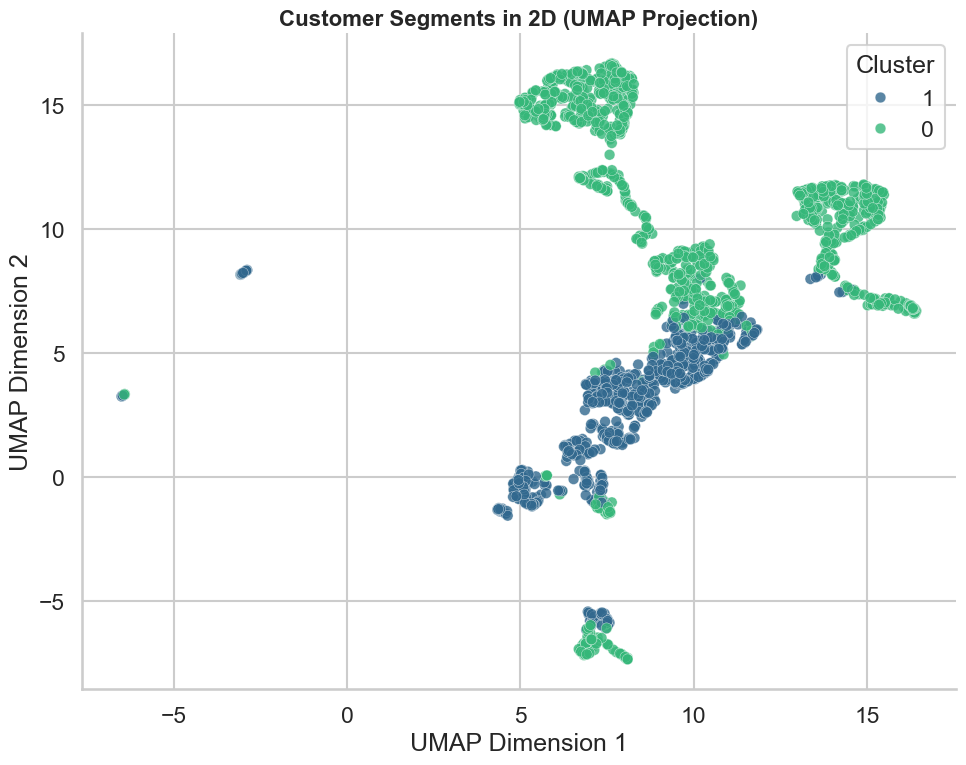

In [5]:
from sklearn.mixture import GaussianMixture

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP not installed. Run `!pip install umap-learn` to see the final plot.")

BOUNDARY_MARGIN = 0.10  # Max gap between top-2 GMM probabilities to flag as "on the fence"


def fit_gmm(pca_data: pd.DataFrame, n_components: int) -> GaussianMixture:
    '''
    Fit a Gaussian Mixture Model for probabilistic ("soft") cluster
    assignment. GMM returns a full probability distribution over all
    clusters per customer -- a more honest reflection of real human
    behavior than a hard K-Means assignment, and operationally useful for
    identifying customers who could be nudged toward a more profitable
    segment with the right campaign.
    '''
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(pca_data)
    return gmm


def find_boundary_customers(gmm: GaussianMixture, pca_data: pd.DataFrame,
                             margin: float = BOUNDARY_MARGIN) -> pd.DataFrame:
    '''
    Identify customers who sit ambiguously between two cluster personas --
    i.e., their top two GMM cluster probabilities are nearly tied. These
    are customers a marketing team should treat carefully: a one-size-fits
    campaign targeted at either persona risks missing them entirely.
    '''
    probabilities = gmm.predict_proba(pca_data)
    sorted_probs = np.sort(probabilities, axis=1)[:, ::-1]

    top1_prob, top2_prob = sorted_probs[:, 0], sorted_probs[:, 1]
    prob_gap = top1_prob - top2_prob

    top1_cluster = np.argsort(probabilities, axis=1)[:, -1]
    top2_cluster = np.argsort(probabilities, axis=1)[:, -2]

    boundary_df = pd.DataFrame(
        {
            "Most_Likely_Cluster": top1_cluster,
            "Most_Likely_Prob": top1_prob.round(3),
            "Second_Likely_Cluster": top2_cluster,
            "Second_Likely_Prob": top2_prob.round(3),
            "Probability_Gap": prob_gap.round(3),
        },
        index=pca_data.index,
    )

    boundary_customers = boundary_df[boundary_df["Probability_Gap"] <= margin]
    return boundary_customers.sort_values("Probability_Gap")


def plot_umap_projection(pca_data: pd.DataFrame, cluster_labels: np.ndarray) -> None:
    '''
    Project the PCA-reduced data down to 2D with UMAP and scatterplot,
    colored by K-Means cluster assignment -- a presentation-quality visual
    for non-technical stakeholders.
    '''
    if not HAS_UMAP:
        print("UMAP is not installed. Run `pip install umap-learn` to generate this plot.")
        return

    reducer = umap.UMAP(n_components=2, random_state=42)
    embedding = reducer.fit_transform(pca_data)

    plot_df = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"])
    plot_df["Cluster"] = cluster_labels.astype(str)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.scatterplot(data=plot_df, x="UMAP1", y="UMAP2", hue="Cluster",
                     palette="viridis", s=60, alpha=0.8,
                     edgecolor="white", linewidth=0.3, ax=ax)
    ax.set_title("Customer Segments in 2D (UMAP Projection)", fontsize=16, fontweight="bold")
    ax.set_xlabel("UMAP Dimension 1")
    ax.set_ylabel("UMAP Dimension 2")
    ax.legend(title="Cluster", loc="best", frameon=True)
    sns.despine()
    fig.tight_layout()
    plt.show()


# --- Advanced Sandbox: GMM Soft Clustering ---
gmm_model = fit_gmm(pca_data, n_components=optimal_k)
boundary_customers = find_boundary_customers(gmm_model, pca_data)

print(f"\nFound {len(boundary_customers)} customers on the boundary "
      f"between two personas (probability gap <= {BOUNDARY_MARGIN}):\n")
print(boundary_customers.head(10).to_string())

# --- Advanced Sandbox: UMAP Visualization ---
plot_umap_projection(pca_data, final_kmeans.labels_)


**Notes:**
- `find_boundary_customers` uses a probability gap threshold rather than requiring an exact 50/50 tie, since true ties are rare in practice — a small gap (≤ 0.10) captures the meaningfully ambiguous customers without being overly strict.
- The UMAP step is guarded with a `try/except` import so the notebook doesn't crash if `umap-learn` isn't installed; it prints an install instruction instead.

---

## Summary

This notebook took a raw, unlabeled retail dataset and, through a fully programmatic pipeline (no manually hardcoded thresholds or cluster counts), produced:

1. A clean, scaled, dimensionality-reduced feature space (PCA).
2. A statistically justified number of customer segments (Silhouette Score).
3. Human-readable, actionable marketing personas (business interpretation).
4. Two advanced extensions — soft clustering (GMM) to catch ambiguous customers, and UMAP for a presentation-ready visualization.

**Next steps for a production deployment:** encode categorical features into the clustering space, add cluster stability testing, and expose personas via a lightweight dashboard for the marketing team.
